# Week 9 — Emotion Forecasting Baselines

## Objective

This week evaluates simple baselines for forecasting the next valid emotion in a MELD conversation.

Given the current utterance emotion \(E_t\), the task is to predict the emotion of the next valid conversational turn \(E_{t+1}\).

Three forecasting baselines are evaluated:

1. Majority — always predicts the most frequent next emotion.
2. Persistence — predicts that the next emotion will remain the same as the current emotion.
3. First-order Markov — predicts the most probable next emotion conditioned on the current emotion using transition probabilities learned from the training set.

Only valid adjacent turns are used. Two utterances are considered adjacent when they belong to the same dialogue and:

\[
\text{next.Utterance\_ID} =
\text{current.Utterance\_ID} + 1
\]

This prevents internal gaps in MELD from being incorrectly treated as conversational adjacency.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

from src.data.loader import load_meld
from src.analysis.forecasting import (
    build_forecasting_examples,
    majority_forecast,
    persistence_forecast,
    fit_markov_model,
    markov_forecast,
)

EMOTIONS = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise",
]

OUTPUT_TABLES = Path("../outputs/tables")
OUTPUT_FIGURES = Path("../outputs/figures")

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
data_dir="/home/chitta/Projects/emotion-dynamics-nlp/data/raw/meld"
meld = load_meld(data_dir)

train = build_forecasting_examples(meld.train)
dev = build_forecasting_examples(meld.dev)
test = build_forecasting_examples(meld.test)

print(f"Train: {len(train)} valid forecasting examples")
print(f"Dev:   {len(dev)} valid forecasting examples")
print(f"Test:  {len(test)} valid forecasting examples")

Train: 8882 valid forecasting examples
Dev:   993 valid forecasting examples
Test:  2328 valid forecasting examples


## Forecasting Baselines

### Majority

The majority baseline predicts the most frequent next-emotion class observed in the training forecasting examples.

### Persistence

The persistence baseline predicts:

\[
\hat{E}_{t+1}=E_t
\]

It therefore assumes that emotional state persists from one valid turn to the next.

### First-order Markov

The Markov baseline estimates:

\[
P(E_{t+1}\mid E_t)
\]

from the training transitions and predicts the most probable next emotion for each current emotion.

No test information is used when fitting the transition probabilities.

In [5]:
pred_majority = majority_forecast(
    train,
    test,
)

pred_persistence = persistence_forecast(test)

markov_model = fit_markov_model(train)

pred_markov = markov_forecast(
    test,
    markov_model,
)

results = {
    "Majority": pred_majority,
    "Persistence": pred_persistence,
    "Markov": pred_markov,
}

y_true = test["next_emotion"]

print("Prediction counts:")
for name, predictions in results.items():
    print(f"{name}: {len(predictions)}")

Prediction counts:
Majority: 2328
Persistence: 2328
Markov: 2328


In [6]:
summary_rows = []

for name, predictions in results.items():
    summary_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Macro F1": f1_score(
            y_true,
            predictions,
            labels=EMOTIONS,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_true,
            predictions,
            labels=EMOTIONS,
            average="weighted",
            zero_division=0,
        ),
    })

summary_df = pd.DataFrame(summary_rows)

summary_df

,Model,Accuracy,Macro F1,Weighted F1
0,Majority,0.479381,0.092583,0.310679
1,Persistence,0.419244,0.273555,0.418594
2,Markov,0.479381,0.092583,0.310679


## Results

The three baselines produce substantially different behavior.

The majority model achieves the highest accuracy by predicting the dominant `neutral` class.

Persistence has lower overall accuracy but substantially higher Macro F1 because it produces predictions across all emotion classes.

The first-order Markov model produces the same result as the majority baseline under the current argmax forecasting formulation. This occurs because `neutral` has the highest transition probability from every source emotion.

In [7]:
summary_df.to_csv(
    OUTPUT_TABLES / "week9_forecasting_results.csv",
    index=False,
)

print(summary_df.to_string(index=False))

      Model  Accuracy  Macro F1  Weighted F1
   Majority  0.479381  0.092583     0.310679
Persistence  0.419244  0.273555     0.418594
     Markov  0.479381  0.092583     0.310679


In [8]:
print("=== Markov Transition Probabilities ===")

markov_model.round(3)

=== Markov Transition Probabilities ===


emotion_to,anger,disgust,fear,joy,neutral,sadness,surprise
emotion_from,,,,,,,
anger,0.317,0.024,0.030,0.104,0.359,0.070,0.096
disgust,0.134,0.164,0.030,0.073,0.366,0.095,0.138
fear,0.138,0.017,0.117,0.134,0.406,0.075,0.113
joy,0.075,0.022,0.023,0.338,0.389,0.046,0.107
neutral,0.083,0.023,0.022,0.148,0.556,0.050,0.118
sadness,0.104,0.035,0.027,0.106,0.342,0.244,0.143
surprise,0.103,0.026,0.028,0.154,0.455,0.068,0.166


## Markov Model Interpretation

The learned transition matrix shows a strong tendency toward `neutral`.

For every source emotion, `neutral` has the highest estimated transition probability:

- anger → neutral: 0.359
- disgust → neutral: 0.366
- fear → neutral: 0.406
- joy → neutral: 0.389
- neutral → neutral: 0.556
- sadness → neutral: 0.342
- surprise → neutral: 0.455

Consequently, the argmax prediction of the first-order Markov model is `neutral` for every source state.

Therefore, its predictions are identical to the majority baseline in this experiment.

In [10]:
for name, predictions in results.items():

    print(f"\n=== {name} ===")

    report = classification_report(
        y_true,
        predictions,
        labels=EMOTIONS,
        target_names=EMOTIONS,
        zero_division=0,
    )

    print(report)


=== Majority ===
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       307
     disgust       0.00      0.00      0.00        63
        fear       0.00      0.00      0.00        44
         joy       0.00      0.00      0.00       358
     neutral       0.48      1.00      0.65      1116
     sadness       0.00      0.00      0.00       187
    surprise       0.00      0.00      0.00       253

    accuracy                           0.48      2328
   macro avg       0.07      0.14      0.09      2328
weighted avg       0.23      0.48      0.31      2328


=== Persistence ===
              precision    recall  f1-score   support

       anger       0.36      0.37      0.37       307
     disgust       0.14      0.13      0.13        63
        fear       0.07      0.07      0.07        44
         joy       0.35      0.34      0.35       358
     neutral       0.57      0.57      0.57      1116
     sadness       0.30      0.29      

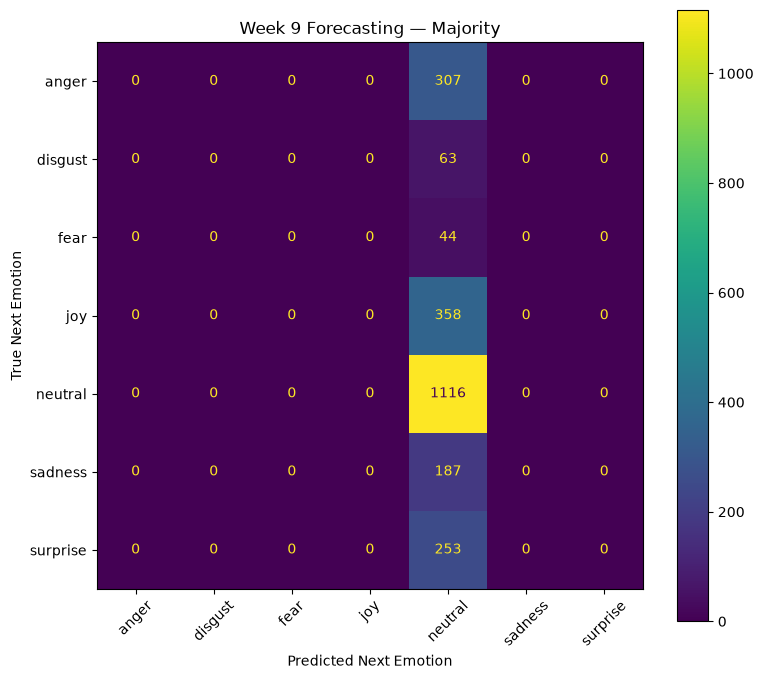

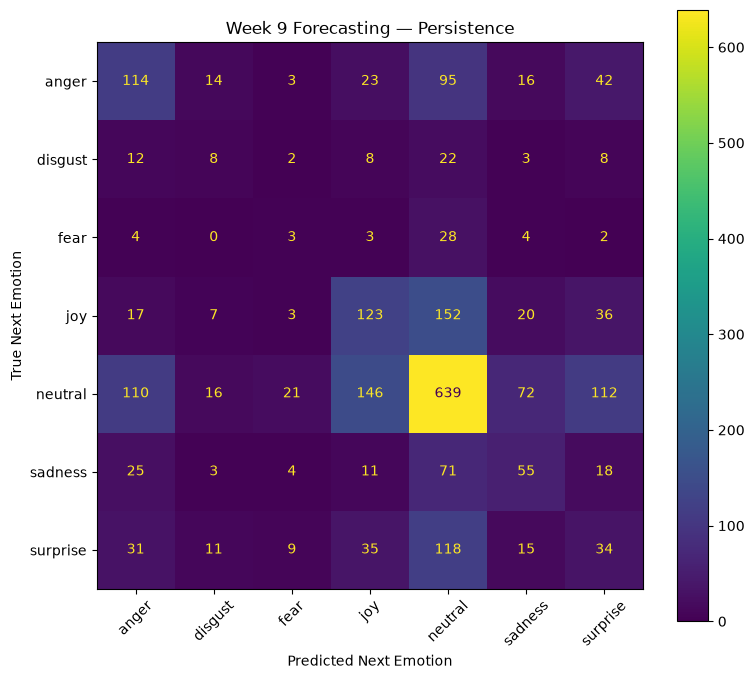

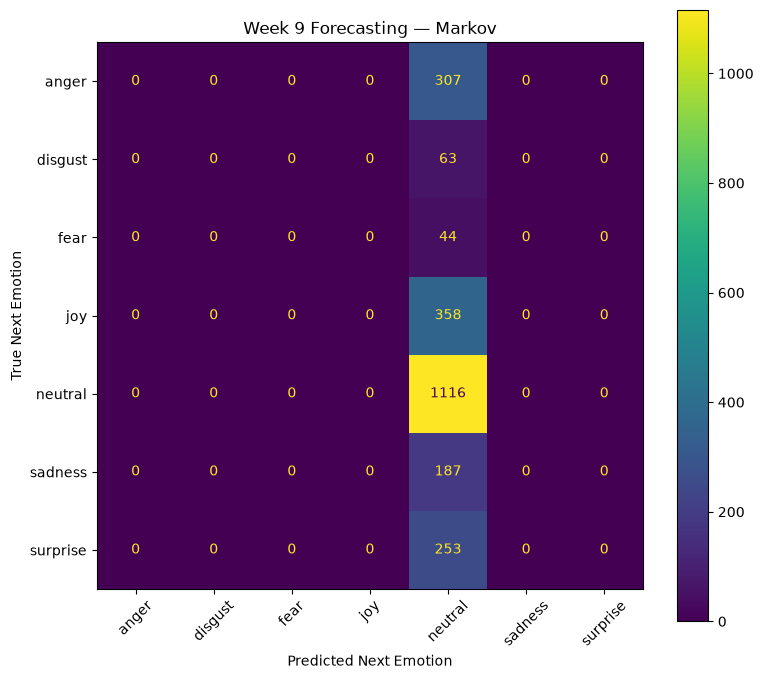

In [11]:
for name, predictions in results.items():

    cm = confusion_matrix(
        y_true,
        predictions,
        labels=EMOTIONS,
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=EMOTIONS,
    )

    display.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d",
    )

    ax.set_title(f"Week 9 Forecasting — {name}")
    ax.set_xlabel("Predicted Next Emotion")
    ax.set_ylabel("True Next Emotion")

    fig.tight_layout()

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    fig.savefig(
        OUTPUT_FIGURES / f"week9_forecasting_confusion_{filename}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

## Key Findings

1. The MELD forecasting task contains substantial emotional persistence, with 41.92% of valid test transitions retaining the current emotion.

2. The majority baseline achieves 47.94% accuracy by predicting `neutral`.

3. Persistence achieves 41.92% accuracy and a Macro F1 of 0.2736, substantially higher than the majority baseline Macro F1 of 0.0926.

4. The first-order Markov model achieves exactly the same metrics as the majority baseline: 47.94% accuracy and 0.0926 Macro F1.

5. The Markov result is explained by the transition matrix: `neutral` is the highest-probability destination from every current emotion.

6. These results demonstrate that simple first-order transition statistics do not provide additional predictive value beyond the dominant-class baseline under this formulation.

7. Persistence is nevertheless an important forecasting baseline because it provides non-zero predictive performance across all seven emotion classes.

### Conclusion

Simple emotion forecasting on MELD is strongly affected by the dominance of the neutral state. A first-order Markov model captures the observed transition structure but, when used with an argmax prediction rule, collapses to the neutral class. Persistence provides a more balanced baseline across emotion classes despite lower overall accuracy.

These results establish the baseline difficulty of the forecasting task and provide a reference point for more context-aware forecasting methods.